In [1]:
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np
import random
import math
import time
import os

In [2]:
prod = lambda v: 1 if not v else v[-1] * prod(v[:-1])

n_choose_k = lambda n, k: prod(range(n-k+1, n+1)) // prod(range(1, k+1))
n_arranj_k = lambda n, k: prod(range(n-k+1, n+1))

### Aplicații task-1: quicksort și quickselect

Vizualizare $P(\text{PIV} = \text{IN})$ în funcție de $m$:

Text(0, 0.5, 'P(Piv = IN)')

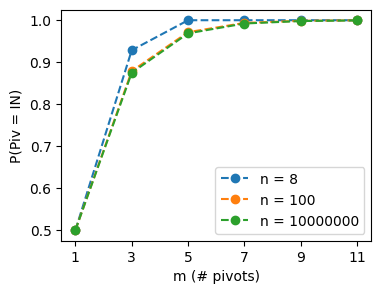

In [39]:
# n elemente, alegem m pivoti.
def proba_piv_out(n, m):
    return 2 * n_choose_k(n//4, (m+1)//2) / n_choose_k(n, (m+1)//2)

fig, ax = plt.subplots(1, 1, figsize = (4, 3))

ox = np.arange(1, 13, 2)
ns = [8, 10**2, 10**7]

for n in ns:
    ax.plot(ox, [1 - proba_piv_out(n, m) for m in ox], ls = "--", marker = 'o')

ax.legend([f"{n = }" for n in ns])

ax.set_xticks(ox)
ax.set_xlabel("m (# pivots)")
ax.set_ylabel("P(Piv = IN)")

### Aplicații task-1: quicksort și quickselect

1. Implementați quicksort non-inplace (varianta prezentată în descriere) și varianta inplace. Comparați timpii de rulare relativ la un algoritm din biblioteca standard, e.g. `std::sort`. Variați $m$.

`input`: Pe prima linie un număr $n$. Pe a doua linie $n$ numere întregi ce trebuie sortate. Se garantează că numerele încap pe $4$ bytes.

`output`: Pe prima linie cele $n$ numere din input sortate. Pe a doua linie adâncimea maximă în arborele de pivoți întalnită de algoritm.

In [3]:
ns = [10**2, 10**3, 10**4, 10**5, 10**6] # marimea input-ului.
runs_per_n = 10

ms = [1, 3, 5, 7] # numarul de pivoti.
p_m = {m: 1 - 1 / 2**m for m in ms} # p(m) din descrierea laboratorului.
ct_m = {m: (13 + 2 * 30**0.5) / (2 * p_m[m]) for m in ms} # c(m) din descrierea laboratorului.

flush_cache_build = "./solution/task-1/builds/flush_cache"
stl_sort_build = "./solution/task-1/builds/sort_stl"

# TODO: înlocuiți cu căile către executabilele voastre.
qsort_inplace_builds = {m: f"./solution/task-1/builds/qsort-inplace_{m}" for m in ms}
qsort_noninplace_builds = {m: f"./solution/task-1/builds/qsort-non-inplace_{m}" for m in ms}

# TODO: puteți să le schimbați și pe acestea dacă vreți.
# acestea sunt fișierele date ca I/O în simulările de mai jos.
infile = "solution/task-1/txts/input.txt"
outfile = "solution/task-1/txts/output.txt"

In [4]:
def make_run(build, array, sorted_array):
    n = len(array)

    with open(f"{infile}", 'w') as fout:
        fout.write(f"{n}\n{' '.join(str(x) for x in array)}\n")

    os.system(flush_cache_build)
    t_start = time.time()
    os.system(f"{build} < {infile} > {outfile}")
    t = time.time() - t_start

    with open(f"{outfile}") as fin:
        v = list(map(int, fin.readline().strip().split()))
        assert len(v) == n, f"({build = }) Expected {n = } numbers, but read {len(v) = } instead."
        assert v == sorted_array, f"Sorted array is not identical to expected sorted array."

        max_depth = int(fin.readline().strip())

    return t, max_depth

def get_stats(name, build, results, arrays, sorted_arrays):
    times, max_depths = [], []
    
    for runid in range(runs_per_n):
        t, max_depth = make_run(build, arrays[runid], sorted_arrays[runid])
        times.append(t)
        max_depths.append(max_depth)
        
    results[name]["time_mean"].append(np.mean(times))
    results[name]["time_std"].append(np.std(times))
    results[name]["max_depth_mean"].append(np.mean(max_depths))
    results[name]["max_depth_std"].append(np.std(max_depths))

In [7]:
results = {
    name: {"time_mean": [], "time_std": [], "max_depth_mean": [], "max_depth_std": []}
    for name in ["stl_sort"] + [f"qsort_inplace_{m}" for m in ms] + [f"qsort_noninplace_{m}"for m in ms]
}

for n in ns:
    t_start = time.time()

    arrays = np.random.randint(0, 1 << 30, size = (runs_per_n, n), dtype = np.int32).tolist()
    sorted_arrays = [sorted(arrays[i]) for i in range(runs_per_n)]
    
    get_stats("stl_sort", stl_sort_build, results, arrays, sorted_arrays)
        
    for m in ms:
        get_stats(f"qsort_inplace_{m}", qsort_inplace_builds[m], results, arrays, sorted_arrays)
        get_stats(f"qsort_noninplace_{m}", qsort_noninplace_builds[m], results, arrays, sorted_arrays)
        
    print(f"Finished {n = } in {round(time.time() - t_start, 3)} s.")
    
# print(results)

Finished n = 100 in 12.15 s.
Finished n = 1000 in 11.934 s.
Finished n = 10000 in 12.562 s.
Finished n = 100000 in 20.534 s.
Finished n = 1000000 in 112.468 s.


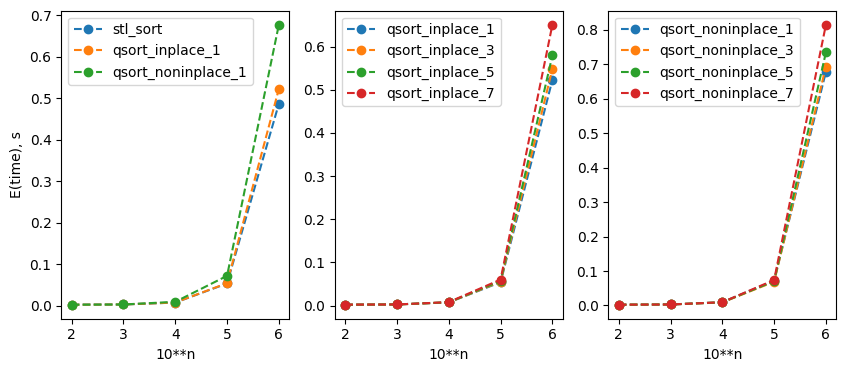

In [35]:
fig, ax = plt.subplots(1, 3, figsize = (10, 4))

for i, types in zip(range(3), [
    ["stl_sort", "qsort_inplace_1", "qsort_noninplace_1"],
    [f"qsort_inplace_{m}" for m in ms],
    [f"qsort_noninplace_{m}" for m in ms]
]):
    for tip in types:
        ax[i].plot(np.log10(ns), results[tip]["time_mean"], ls = "--", marker = 'o')

    ax[i].legend(types)
    ax[i].set_xlabel("10**n")
    if i == 0:
        ax[i].set_ylabel("E(time), s")

### Aplicații task-1: quicksort și quickselect

2. Creați un plot cu adâncimea maximă a unui arbore pivot peste mai multe valori ale lui $m$. Creați o histogramă cu adâncimea maximă pentru un $m$ specific. Estimați probabilitatea ca adâncimea să depășească $c(m) \ln n$ (Monte Carlo) și comparați-o cu cea obținută teoretic, i.e. $n^{-2}$.

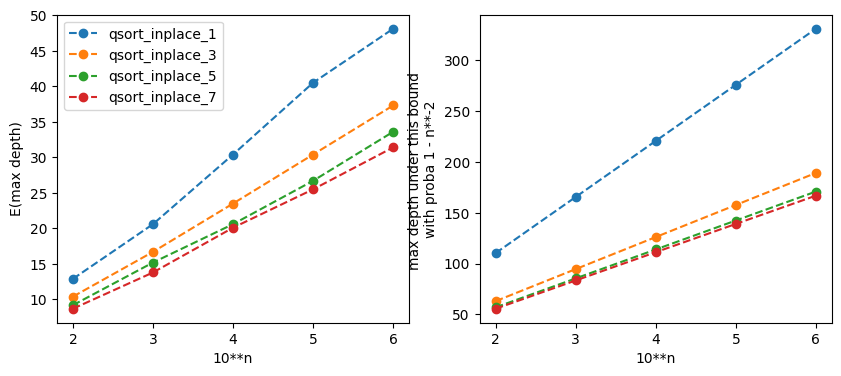

In [55]:
# TODO: trebuie doar sa rulati casutele aici. aveti grija sa fie populat results de mai sus.

fig, ax = plt.subplots(1, 2, figsize = (10, 4))

types = [f"qsort_inplace_{m}" for m in ms]
for tip in types:
    ax[0].plot(np.log10(ns), results[tip]["max_depth_mean"], ls = "--", marker = 'o')

ax[0].legend(types)
ax[0].set_xlabel("10**n")
ax[0].set_ylabel("E(max depth)")
    
for m in ms:
    ax[1].plot(np.log10(ns), ct_m[m] * np.log(ns), ls = "--", marker = 'o')
    ax[1].set_xlabel("10**n")
    ax[1].set_ylabel("max depth under this bound \nwith proba 1 - n**-2")

# uncomment these to be able to actually compare ranges:
# ax[0].set_ylim([0, 350])
# ax[1].set_ylim([0, 350])

In [24]:
n = 100
cnt_runs = 1000

arrays = np.random.randint(0, 1 << 30, size = (cnt_runs, n), dtype = np.int32).tolist()
sorted_arrays = [sorted(arrays[i]) for i in range(cnt_runs)]

max_depths = []
for runid in tqdm(range(cnt_runs)):
    _, max_depth = make_run(qsort_inplace_builds[3], arrays[runid], sorted_arrays[runid])
    max_depths.append(max_depth)
    
# vrem sa simulam n mic pentru a avea probabilitate mai mare de a depasi limita noastra, e.g. proba n**-2.
# insa avem nevoie de n mare pentru a avea limita sub adancimea maxima teoretica a arborelui.
# deci este dificil si de a observa in practica o trecere peste limita:
# (1 - n**-2) este o estimare conservatoare a probabilitatii de a nu depasi adancimea c(m)ln(n).
print(max(max_depths), ct_m[3] * math.log(n))

# n = 10: max(max_depths) = 7, lim ~= 31.51 (cnt_runs = 1000)
# n = 100: max(max_depths) = 14, lim ~= 63.03 (cnt_runs = 1000)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [02:32<00:00,  6.56it/s]

14 63.036756718950855


Text(0.5, 0, 'max observed depth (n = 100)')

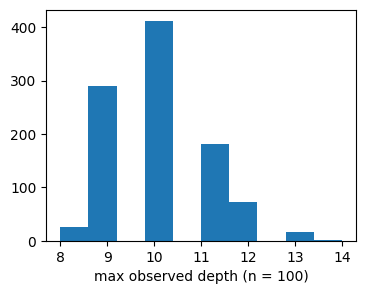

In [28]:
fig, ax = plt.subplots(1, 1, figsize = (4, 3))
ax.stairs(*np.histogram(max_depths), fill = True)
ax.set_xlabel(f"max observed depth ({n = })")

### Aplicații task-2: Hashuri polinomiale. Birthday paradox

Vizualizare Birthday paradox. Variați $n$ mai jos, e.g. $365$ zile/an, $30$ zile/lună, $12$ luni/an.

Text(0, 0.5, 'Proba of at least a collision')

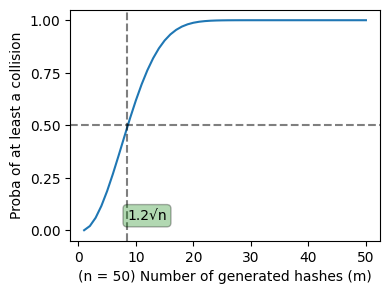

In [38]:
n = 50
fig, ax = plt.subplots(1, 1, figsize = (4, 3))

ax.plot(range(1, n+1), [1 - n_arranj_k(n, m) / n**m for m in range(1, n+1)])
ax.axhline(0.5, c = 'k', alpha = 0.5, ls = "--")
ax.axvline(1.2 * n**0.5, c = 'k', alpha = 0.5, ls = "--")

ax.set_yticks(np.arange(0, 1 + 0.1, 0.25))

ax.text(1.2 * n**0.5, 0.05, "1.2√n").set_bbox(dict(boxstyle = "round", facecolor = "green", alpha = 0.3))

ax.set_xlabel(f"({n = }) Number of generated hashes (m)")
ax.set_ylabel("Proba of at least a collision")

### Aplicații task-2: Hashuri polinomiale. Birthday paradox

4. Câte subsecvențe distincte de lungime $k$ există într-un string $s$? Câte comparații între hash-uri face algoritmul vostru? Estimați $P(\nexists)$. Implementați cel puțin încă o rezolvare a problemei care sa fie deterministă, e.g. inserări într-un trie sau sortări peste subsecvențele de lungime $k$ cu un comparator custom. Comparați viteza și corectitudinea soluției deterministe cu cea Monte-Carlo.

Folosiți `skel/task-2/distinct-substrings.cpp` pentru implementarea cu hash-uri. Vă rugăm să folosiți $\text{MOD} = 10^9 + 7$ și o singură bază aleatoare pentru a putea compara rezultatele cu cele de mai jos.

Estimare pentru $N = 10^4$, $K = 100$: $P(\nexists \text{ coliziuni}) \simeq 0.952$.

Folosiți `skel/task-2/distinct-substrings-det.cpp` pentru implementarea voastră deterministă.

`input`: Pe prima linie un string $s$ format din doar caractere minuscule ale alfabetului latin. Pe a doua linie un număr $k \in \{1, |s|\}$.

`output`: Un singur număr, câte subsecvențe distincte de lungime $k$ există în $s$.

In [33]:
# TODO: înlocuiți cu căile către executabilele voastre. e ok o singură implementare deterministă de la voi.
ht = {
    "hashes": {"build": "./solution/task-2/builds/distinct-substrings", "results": []},
    "det-sort": {"build": "./solution/task-2/builds/distinct-substrings-det-sort", "results": []}
    # "det-trie": {"build": "./solution/task-2/builds/distinct-substrings-det-trie", "results": []}
}

# TODO: puteți să le schimbați și pe acestea dacă vreți.
# acestea sunt fișierele date ca I/O în simulările de mai jos.
infile = "solution/task-2/txts/input.txt"
outfile = "solution/task-2/txts/output.txt"

n = 10**4
k = 100
cnt_runs = 5000

strs = [''.join(map(chr, v)) for v in (np.random.randint(0, 26, size = (cnt_runs, n)) + ord('a')).tolist()]

for tip in ht:
    t_start_tip = time.time()

    for runid in tqdm(range(cnt_runs)):
        with open(f"{infile}", 'w') as fout:
            fout.write(f"{strs[runid]}\n{k}\n")

        t_start = time.time()
        os.system(f"{ht[tip]['build']} < {infile} > {outfile}")
        t = time.time() - t_start

        with open(f"{outfile}") as fin:
            cnt = int(fin.readline().strip())
            
        ht[tip]["results"].append(cnt)
    
    print(f"Finished {tip = } in {round(time.time() - t_start_tip, 3)} s.")

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5000/5000 [00:16<00:00, 303.27it/s]


Finished tip = 'hashes' in 16.489 s.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5000/5000 [01:06<00:00, 75.68it/s]

Finished tip = 'det-sort' in 66.071 s.


In [34]:
(np.array(ht["hashes"]["results"]) == np.array(ht["det-sort"]["results"])).sum() / cnt_runs

0.9528